In [1]:
import numpy as np 
import pandas as pd 


In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df = df.iloc[:,2:]

In [4]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

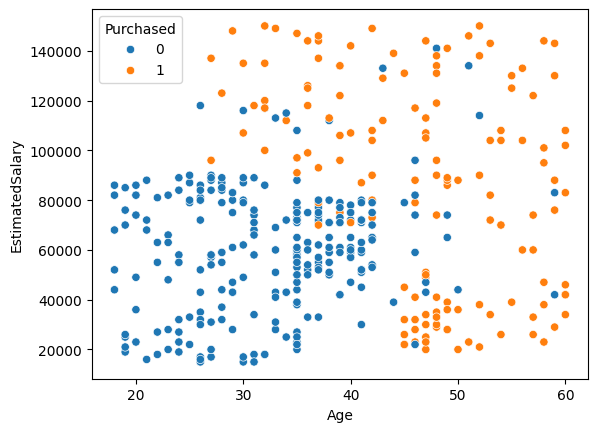

In [6]:
sns.scatterplot(x=df['Age'], y=df['EstimatedSalary'],hue=df['Purchased'])

In [7]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]

In [8]:
X,y

(     Age  EstimatedSalary
 0     19            19000
 1     35            20000
 2     26            43000
 3     27            57000
 4     19            76000
 ..   ...              ...
 395   46            41000
 396   51            23000
 397   50            20000
 398   36            33000
 399   49            36000
 
 [400 rows x 2 columns],
 0      0
 1      0
 2      0
 3      0
 4      0
       ..
 395    1
 396    1
 397    1
 398    0
 399    1
 Name: Purchased, Length: 400, dtype: int64)

In [9]:
from sklearn.model_selection import train_test_split as tts 
X_train,X_test,y_train,y_test = tts(X,y,test_size=0.2, random_state=2)

In [10]:
import tensorflow as tf 
from tensorflow import keras 
from keras.models import Sequential 
from keras.layers import Dense

In [11]:
model =Sequential()

model.add(Dense(128, activation='relu', input_dim=2))
model.add(Dense(1,activation='sigmoid'))

c:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
history = model.fit(X_train ,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.6531 - loss: 2809.3523 - val_accuracy: 0.6000 - val_loss: 1044.8939
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4781 - loss: 735.0104 - val_accuracy: 0.4000 - val_loss: 659.7852
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5594 - loss: 303.9847 - val_accuracy: 0.6000 - val_loss: 162.0532
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4594 - loss: 166.2697 - val_accuracy: 0.6000 - val_loss: 283.4413
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5281 - loss: 198.7873 - val_accuracy: 0.4000 - val_loss: 147.0326
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5969 - loss: 170.1350 - val_accuracy: 0.4000 - val_loss: 97.1466
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4844 - loss: 110.9758 - val_accuracy: 0.4000 - val_loss: 61.4012
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4594 - lo

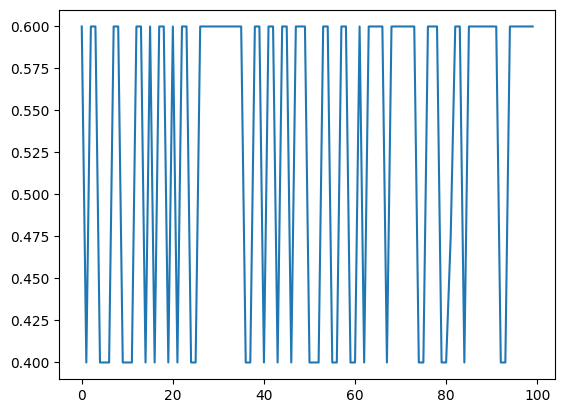

In [15]:
import matplotlib.pyplot as plt 
plt.plot(history.history['val_accuracy'])

In [16]:
# accuracy oscillates betn .4 to .6 but didnt converge as the input 1 and input 2 are both on very different scale leading to this problem

In [17]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.fit_transform(X_test)


In [18]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,  activation='sigmoid'))

c:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
history = model.fit(X_train_scaled,y_train, validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6187 - loss: 0.6570 - val_accuracy: 0.7500 - val_loss: 0.6196
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8156 - loss: 0.6049 - val_accuracy: 0.8625 - val_loss: 0.5702
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8313 - loss: 0.5602 - val_accuracy: 0.8375 - val_loss: 0.5270
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8594 - loss: 0.5206 - val_accuracy: 0.8000 - val_loss: 0.4906
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8531 - loss: 0.4869 - val_accuracy: 0.8125 - val_loss: 0.4588
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8531 - loss: 0.4565 - val_accuracy: 0.8000 - val_loss: 0.4319
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8594 - loss: 0.4305 - val_accuracy: 0.8125 - val_loss: 0.4089
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8594 - loss: 0.4080 - val_accuracy: 0.

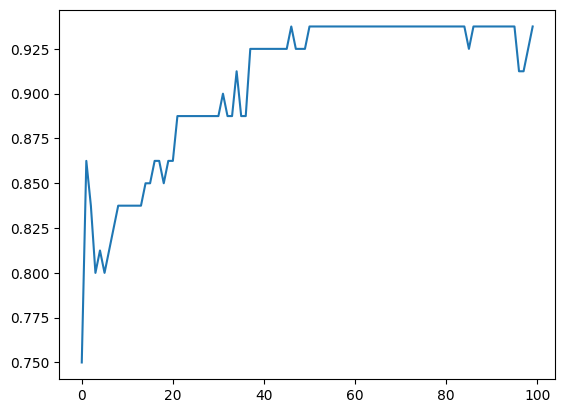

In [22]:
plt.plot(history.history['val_accuracy'])